<a href="https://colab.research.google.com/github/SafaaMahbub/ML-Project-2/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics Lab

#Members

**Member 1**: Alexander Scott, hmn7zu, AlxScottt

**Alex Sources**: I used grammerly and google docs to fix my spelling. Also used chatGPT to double check what I said make sense.

Q7: Understand and context
https://pmc.ncbi.nlm.nih.gov/articles/PMC9896544/


Q8: This was for looking at Lasso downsides.
https://stats.stackexchange.com/questions/7935/what-are-disadvantages-of-using-the-lasso-for-variable-selection-for-regression

More context
https://pmc.ncbi.nlm.nih.gov/articles/PMC11751774/




Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [ ]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 214 (delta 79), reused 39 (delta 39), pack-reused 122 (from 1)
Receiving objects: 100% (214/214), 16.42 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (103/103), done.


In [ ]:
import pandas as pd
df = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')
print(df.head())
df.columns

   Samples BM.PB Gender Source tissue.mf cancer  AFFX-BioB-5_at  \
0       39    BM      F   DFCI      BM:f   allB    -1363.276427   
1       40    BM      F   DFCI      BM:f   allB     -796.285053   
2       42    BM      F   DFCI      BM:f   allB     -679.139168   
3       47    BM      M   DFCI      BM:m   allB    -1164.400197   
4       48    BM      F   DFCI      BM:f   allB    -1299.653758   

   AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  ...   U48730_at  \
0    -1058.585495     -541.469194       74.349803  ...  -35.081447   
1    -1167.103365        7.538493       83.544731  ... -404.737767   
2    -1069.832308     -690.301829     -112.075981  ...  193.780934   
3    -1109.939891     -990.127218     -238.574994  ... -256.002292   
4    -1401.998536    -1077.543813     -437.344560  ... -509.203660   

     U58516_at    U73738_at   X06956_at    X16699_at    X83863_at   Z17240_at  \
0  1565.618803  -485.680714 -170.261227  -919.114293  1675.050053  389.769289   
1   622.498054

Index(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer',
       'AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioB-3_at', 'AFFX-BioC-5_at',
       ...
       'U48730_at', 'U58516_at', 'U73738_at', 'X06956_at', 'X16699_at',
       'X83863_at', 'Z17240_at', 'L49218_f_at', 'M71243_f_at', 'Z78285_f_at'],
      dtype='object', length=7135)

In [ ]:
mapper = {'allB':0,
          'allT':0,
          'aml':1}

df['target'] = df['cancer'].map(mapper)
counts = df['target'].value_counts()
print(counts)

target
0    47
1    25
Name: count, dtype: int64


Mean Squared Error (Training): 0.0000


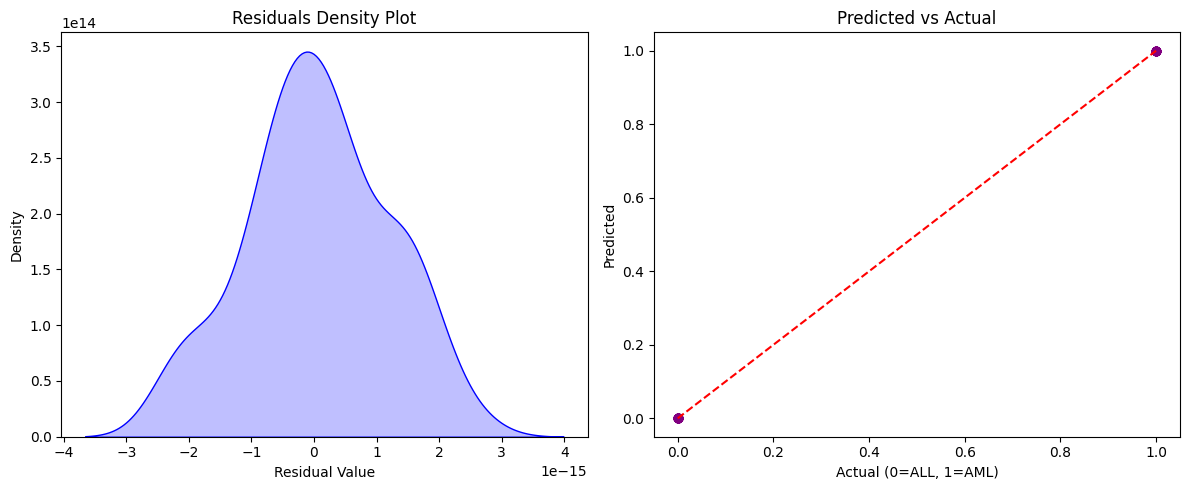

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

X = df.loc[:, 'AFFX-BioB-5_at':'Z78285_f_at']
y = df['target']

lr_model = LinearRegression()
lr_model.fit(X, y)
y_pred = lr_model.predict(X)

#calculate MSE
mse_train = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (Training): {mse_train:.4f}")

residuals = y - y_pred

plt.figure(figsize=(12, 5))

#kernel density plot of residuals
plt.subplot(1, 2, 1)
sns.kdeplot(residuals, fill=True, color="blue")
plt.title('Residuals Density Plot')
plt.xlabel('Residual Value')

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred, alpha=0.6, color="purple")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Predicted vs Actual')
plt.xlabel('Actual (0=ALL, 1=AML)')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

X = df.loc[:, 'AFFX-BioB-5_at':'Z78285_f_at']
y = df['target']

# 5-fold Cross-Validation
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_squared_error')

#convert to positive MSE and take the average
mse_cv = -cv_scores.mean()

print(f"Cross-Validated MSE: {mse_cv}")

Cross-Validated MSE: 0.06012309872062149


The massive gap between our training MSE (0) and CV MSE (~1.27) is a textbook case of high variance. With 7,000+ genes but only 72 samples, the model has low bias and basically just memorized the training data instead of finding real patterns. This leads to heavy overfitting, where the model captures random noise that doesn't actually exist in new samples, causing the error to spike during cross-validation.

Number of discarded Genes: 7048
Number of selected Genes: 81
Selected Genes: ['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'K02777_s_at', 'U37055_rna1_s_at', 'U5

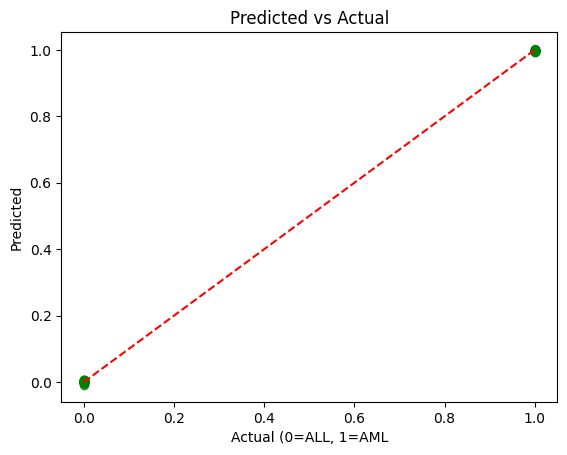

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler();
X_scaled = scaler.fit_transform(X)

lasso_model = LassoCV(cv=10, random_state=100,max_iter=10_000)
lasso_model.fit(X_scaled, y)

coefficients = pd.Series(lasso_model.coef_, index=X.columns)
discarded_genes = (coefficients == 0).sum()
selected_genes_sum = (coefficients !=0).sum()
print(f"Number of discarded Genes: {discarded_genes}")
print(f"Number of selected Genes: {selected_genes_sum}")
selected_genes = coefficients[coefficients != 0].index.tolist()

print(f"Selected Genes: {selected_genes}")

y_predictions = lasso_model.predict(X_scaled)

plt.figure()
plt.scatter(y, y_predictions, alpha=0.7, color="green")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Predicted vs Actual')
plt.xlabel('Actual (0=ALL, 1=AML')
plt.ylabel('Predicted')

plt.show()


# Q5)

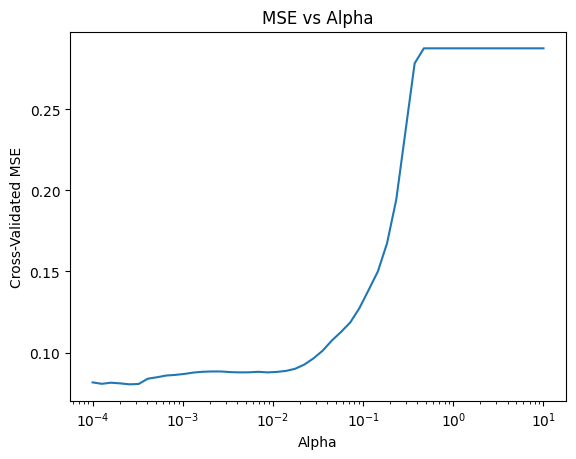

In [ ]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

alphas = np.logspace(-4, 1, 50)
mse_list = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    scores = cross_val_score(lasso, X_scaled, y,
                             cv=5,
                             scoring='neg_mean_squared_error')
    mse_list.append(-scores.mean())

plt.figure()
plt.plot(alphas, mse_list)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validated MSE')
plt.title('MSE vs Alpha')
plt.show()

The plot shows the bias–variance trade-off as α changes. For very small α values, the MSE is low but the model is overfitting, behaving like linear regression and capturing noise. As α increases to around
10^−3 10^−2, the MSE reaches its minimum, indicating the optimal balance between bias and variance. For larger α values (above
10^−1), the MSE rises sharply, showing underfitting due to excessive regularization. Thus, the optimal α is in the range 10^−3 to
10^−2.

# Q6

Linear regression performs perfectly on the training set because there are far more predictors than observations, so the model can exactly fit the training data. However, this causes overfitting, meaning it memorizes noise rather than learning patterns that generalize well.

LASSO gives better overall predictions because it adds a penalty that shrinks coefficients and sets many of them to zero. This reduces model complexity, lowers variance, and helps the model focus on the most important genes. As a result, LASSO generalizes better to new data even if it is not perfect on the training set.

#Q7

In healthcare contexts, there are large amounts of variables involved in patient data. You have testing results, images (CT-Scans, MRI's, X-rays), prescriptions, medication, current vitals, active observational data, allergies and medical history.

Regularization methods allow for those variables to not create excess noise, ensuring that models make more accurate predictions. It identifies the most relevant predictors, discarding excess redundancy. Therefore, reducing overfitting and making a more accurate prediction.


#Q8

By applying regression (like Lasso) to precision health predictors, you can end up with data that is unnecessarily biased. For example, if the data you feed into a model is primarily sourced from white populations, it can fail to make accurate predictions for minority populations.

Moreover, sometimes by using regularization, the data can be underfitted, meaning in real-world applications, the model can make decisions that are entirely wrong when given new situations.



